In [ ]:
# 第一步：挂载 Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

# 根据你截图，路径是 My Drive > utd_mhad
BASE_DIR     = "/content/drive/MyDrive/utd_mhad"
SKELETON_DIR = os.path.join(BASE_DIR, "Skeleton")
INERTIAL_DIR = os.path.join(BASE_DIR, "Inertial")

# 验证路径是否正确
print(os.listdir(BASE_DIR))        # 应该看到 Skeleton, Inertial, Depth...
print(os.listdir(SKELETON_DIR)[:5]) # 应该看到 a1_s1_t1_skeleton.mat ...

import scipy.io as sio
import numpy as np


# 探查一个skeleton文件
sk_path = os.path.join(SKELETON_DIR, "a1_s1_t1_skeleton.mat")
mat = sio.loadmat(sk_path)

print("=== Skeleton file keys ===")
# 过滤掉scipy自动加的元数据key
keys = [k for k in mat.keys() if not k.startswith('__')]
print(keys)

for k in keys:
    print(f"  key='{k}', shape={mat[k].shape}, dtype={mat[k].dtype}")

# 探查一个inertial文件
im_path = os.path.join(INERTIAL_DIR, "a1_s1_t1_inertial.mat")
mat2 = sio.loadmat(im_path)

print("\n=== Inertial file keys ===")
keys2 = [k for k in mat2.keys() if not k.startswith('__')]
print(keys2)

for k in keys2:
    print(f"  key='{k}', shape={mat2[k].shape}, dtype={mat2[k].dtype}")

Mounted at /content/drive
['Depth', 'Inertial', 'Sample_Code', 'Skeleton', 'RGB-part2', 'RGB-part1', 'RGB-part3', 'RGB-part4']
['a1_s1_t1_skeleton.mat', 'a1_s1_t2_skeleton.mat', 'a1_s1_t3_skeleton.mat', 'a1_s1_t4_skeleton.mat', 'a2_s1_t1_skeleton.mat']
=== Skeleton file keys ===
['d_skel']
  key='d_skel', shape=(20, 3, 48), dtype=float64

=== Inertial file keys ===
['d_iner']
  key='d_iner', shape=(160, 6), dtype=float64


In [ ]:
# ============================================================
# CELL 1: 安装依赖 + 挂载（如果还没挂载）
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, warnings
import numpy as np
import scipy.io as sio
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu


In [ ]:
# ============================================================
# CELL 2: 路径 + 参数配置
# ============================================================
BASE_DIR     = "/content/drive/MyDrive/utd_mhad"
SKELETON_DIR = os.path.join(BASE_DIR, "Skeleton")
INERTIAL_DIR = os.path.join(BASE_DIR, "Inertial")

HIGH_DYNAMIC_ACTIONS = [5, 7, 12, 14, 15, 17]
TRAIN_SUBJECTS       = [1, 3, 5, 7]
TEST_SUBJECTS        = [2, 4, 6, 8]
TARGET_LEN           = 100
NUM_CLASSES          = 6
WINDOW_SIZE          = 20   # 滑动窗口大小（占总长度20%）

In [ ]:
# ============================================================
# CELL 3: 数据加载
# ============================================================
def load_skeleton(filepath):
    mat  = sio.loadmat(filepath)
    skel = mat['d_skel']              # (20, 3, T)
    skel = skel.transpose(2, 0, 1)   # → (T, 20, 3)
    T    = skel.shape[0]
    return skel.reshape(T, -1).astype(np.float32)  # → (T, 60)

def load_inertial(filepath):
    mat  = sio.loadmat(filepath)
    iner = mat['d_iner']              # (T, 6) 已经正确
    return iner.astype(np.float32)

def normalize_length(seq, target_len=TARGET_LEN):
    T = seq.shape[0]
    if T == target_len:
        return seq
    x_old = np.linspace(0, 1, T)
    x_new = np.linspace(0, 1, target_len)
    out   = np.zeros((target_len, seq.shape[1]), dtype=np.float32)
    for d in range(seq.shape[1]):
        out[:, d] = interp1d(x_old, seq[:, d])(x_new)
    return out

def load_dataset():
    action_to_class = {a: i for i, a in enumerate(HIGH_DYNAMIC_ACTIONS)}
    train_sk, train_im, train_lb = [], [], []
    test_sk,  test_im,  test_lb  = [], [], []
    test_subj = []
    skipped   = 0

    for a in HIGH_DYNAMIC_ACTIONS:
        for s in range(1, 9):
            for t in range(1, 5):
                sk_path = os.path.join(SKELETON_DIR,
                                       f"a{a}_s{s}_t{t}_skeleton.mat")
                im_path = os.path.join(INERTIAL_DIR,
                                       f"a{a}_s{s}_t{t}_inertial.mat")

                if not os.path.exists(sk_path) or \
                   not os.path.exists(im_path):
                    skipped += 1
                    continue

                try:
                    sk = normalize_length(load_skeleton(sk_path))
                    im = normalize_length(load_inertial(im_path))
                except Exception as e:
                    print(f"Error: {sk_path} → {e}")
                    skipped += 1
                    continue

                label = action_to_class[a]
                if s in TRAIN_SUBJECTS:
                    train_sk.append(sk); train_im.append(im)
                    train_lb.append(label)
                else:
                    test_sk.append(sk);  test_im.append(im)
                    test_lb.append(label); test_subj.append(s)

    print(f"Skipped: {skipped} files")
    return (np.array(train_sk), np.array(train_im), np.array(train_lb),
            np.array(test_sk),  np.array(test_im),  np.array(test_lb),
            np.array(test_subj))

(train_sk, train_im, train_lb,
 test_sk,  test_im,  test_lb, test_subj) = load_dataset()

print(f"Train: {len(train_lb)} sequences | "
      f"Label dist: {np.bincount(train_lb)}")
print(f"Test:  {len(test_lb)}  sequences | "
      f"Label dist: {np.bincount(test_lb)}")
print(f"Skeleton shape: {train_sk.shape}")  # 期待 (N, 100, 60)
print(f"IMU shape:      {train_im.shape}")  # 期待 (N, 100, 6)

Skipped: 0 files
Train: 96 sequences | Label dist: [16 16 16 16 16 16]
Test:  96  sequences | Label dist: [16 16 16 16 16 16]
Skeleton shape: (96, 100, 60)
IMU shape:      (96, 100, 6)


In [ ]:
# ============================================================
# CELL 4: 归一化
# ============================================================
def normalize_features(train_data, test_data):
    N, T, D    = train_data.shape
    flat       = train_data.reshape(-1, D)
    mean       = flat.mean(axis=0)
    std        = flat.std(axis=0) + 1e-8
    return ((train_data - mean) / std).astype(np.float32), \
           ((test_data  - mean) / std).astype(np.float32)

train_sk_n, test_sk_n = normalize_features(train_sk, test_sk)
train_im_n, test_im_n = normalize_features(train_im, test_im)
print("Normalization done.")
print(f"Skeleton mean≈{train_sk_n.mean():.4f}, std≈{train_sk_n.std():.4f}")
print(f"IMU     mean≈{train_im_n.mean():.4f}, std≈{train_im_n.std():.4f}")

Normalization done.
Skeleton mean≈-0.0000, std≈1.0000
IMU     mean≈0.0000, std≈1.0000


In [ ]:
# ============================================================
# CELL 5: 模型定义
# ============================================================
class SkeletonClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(60, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(256, NUM_CLASSES)

    def forward(self, x):
        # x: (B, 100, 60)
        feat = self.net(x.transpose(1,2)).squeeze(-1)  # (B,256)
        return self.fc(feat)

    def get_features(self, x):
        return self.net(x.transpose(1,2)).squeeze(-1)

class IMUClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(6, 64,  kernel_size=5, padding=2),
            nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(256, NUM_CLASSES)

    def forward(self, x):
        # x: (B, 100, 6)
        feat = self.net(x.transpose(1,2)).squeeze(-1)
        return self.fc(feat)

    def get_features(self, x):
        return self.net(x.transpose(1,2)).squeeze(-1)

In [ ]:
# ============================================================
# CELL 6: 训练函数
# ============================================================
def train_model(model, train_X, train_y, test_X, test_y,
                n_epochs=150, batch_size=32, lr=1e-3, name="Model"):

    X_tr = torch.FloatTensor(train_X)
    y_tr = torch.LongTensor(train_y)
    X_te = torch.FloatTensor(test_X).to(DEVICE)
    y_te = torch.LongTensor(test_y)

    loader = DataLoader(TensorDataset(X_tr, y_tr),
                        batch_size=batch_size, shuffle=True)

    model    = model.to(DEVICE)
    opt      = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched    = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    criterion = nn.CrossEntropyLoss()

    best_acc, best_state = 0, None

    for epoch in range(1, n_epochs + 1):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            criterion(model(xb), yb).backward()
            opt.step()
        sched.step()

        if epoch % 25 == 0:
            model.eval()
            with torch.no_grad():
                preds = model(X_te).argmax(1).cpu()
            acc = (preds == y_te).float().mean().item()
            print(f"[{name}] Epoch {epoch:3d} | Test Acc: {acc:.4f}")
            if acc > best_acc:
                best_acc = acc
                best_state = {k: v.clone()
                              for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    print(f"\n✓ [{name}] Best Acc = {best_acc:.4f}\n")
    return model

print("Training Vision (Skeleton) model...")
vision_model = train_model(
    SkeletonClassifier(),
    train_sk_n, train_lb,
    test_sk_n,  test_lb,
    name="Vision"
)

print("Training IMU model...")
imu_model = train_model(
    IMUClassifier(),
    train_im_n, train_lb,
    test_im_n,  test_lb,
    name="IMU"
)

Training Vision (Skeleton) model...
[Vision] Epoch  25 | Test Acc: 0.7500
[Vision] Epoch  50 | Test Acc: 0.7708
[Vision] Epoch  75 | Test Acc: 0.7604
[Vision] Epoch 100 | Test Acc: 0.7604
[Vision] Epoch 125 | Test Acc: 0.7604
[Vision] Epoch 150 | Test Acc: 0.7604

✓ [Vision] Best Acc = 0.7708

Training IMU model...
[IMU] Epoch  25 | Test Acc: 0.7188
[IMU] Epoch  50 | Test Acc: 0.7917
[IMU] Epoch  75 | Test Acc: 0.8229
[IMU] Epoch 100 | Test Acc: 0.7917
[IMU] Epoch 125 | Test Acc: 0.8021
[IMU] Epoch 150 | Test Acc: 0.8021

✓ [IMU] Best Acc = 0.8229



In [ ]:
# ============================================================
# CELL 7: 滑动窗口评估
# ============================================================
def window_accuracy(model, seqs, labels, t_start, t_end):
    """
    用序列的 [t_start, t_end] 段做预测，返回 accuracy
    seqs: numpy (N, 100, D)
    """
    model.eval()
    window = seqs[:, t_start:t_end, :]          # (N, W, D)

    # 重采样到 TARGET_LEN
    N, W, D = window.shape
    resampled = np.zeros((N, TARGET_LEN, D), dtype=np.float32)
    for i in range(N):
        resampled[i] = normalize_length(window[i], TARGET_LEN)

    X = torch.FloatTensor(resampled).to(DEVICE)
    y = torch.LongTensor(labels)
    with torch.no_grad():
        preds = model(X).argmax(1).cpu()
    return (preds == y).float().mean().item()

# 全局扫描
time_centers, accs_v, accs_i = [], [], []

for t in range(0, TARGET_LEN - WINDOW_SIZE + 1, 5):
    av = window_accuracy(vision_model, test_sk_n, test_lb, t, t+WINDOW_SIZE)
    ai = window_accuracy(imu_model,    test_im_n, test_lb, t, t+WINDOW_SIZE)
    accs_v.append(av)
    accs_i.append(ai)
    time_centers.append(t + WINDOW_SIZE // 2)

accs_v = np.array(accs_v)
accs_i = np.array(accs_i)
gaps   = accs_i - accs_v

print("Time | Vision | IMU   | Gap")
print("-" * 35)
for t, v, i, g in zip(time_centers, accs_v, accs_i, gaps):
    print(f"t={t:3d}%  {v:.3f}   {i:.3f}   {g:+.3f}")

Time | Vision | IMU   | Gap
-----------------------------------
t= 10%  0.500   0.240   -0.260
t= 15%  0.688   0.542   -0.146
t= 20%  0.781   0.625   -0.156
t= 25%  0.781   0.542   -0.240
t= 30%  0.833   0.635   -0.198
t= 35%  0.844   0.615   -0.229
t= 40%  0.833   0.615   -0.219
t= 45%  0.802   0.594   -0.208
t= 50%  0.771   0.604   -0.167
t= 55%  0.719   0.510   -0.208
t= 60%  0.719   0.438   -0.281
t= 65%  0.646   0.396   -0.250
t= 70%  0.562   0.365   -0.198
t= 75%  0.438   0.396   -0.042
t= 80%  0.417   0.385   -0.031
t= 85%  0.354   0.219   -0.135
t= 90%  0.354   0.167   -0.187


In [ ]:
# ============================================================
# CELL 8: Per-Subject Gap 分析 + 统计检验
# ============================================================
subject_gaps = {}

for subj in TEST_SUBJECTS:
    mask = (test_subj == subj)
    sk_s = test_sk_n[mask]
    im_s = test_im_n[mask]
    lb_s = test_lb[mask]

    g_list = []
    for t in range(0, TARGET_LEN - WINDOW_SIZE + 1, 5):
        av = window_accuracy(vision_model, sk_s, lb_s, t, t+WINDOW_SIZE)
        ai = window_accuracy(imu_model,    im_s, lb_s, t, t+WINDOW_SIZE)
        g_list.append(ai - av)
    subject_gaps[subj] = np.array(g_list)

# (4, n_timepoints)
gap_matrix = np.stack([subject_gaps[s] for s in TEST_SUBJECTS])
mean_gap   = gap_matrix.mean(axis=0)
sem_gap    = gap_matrix.std(axis=0) / np.sqrt(4)

# Preparation vs Impact
time_arr    = np.array(time_centers)
prep_mask   = (time_arr >= 0)  & (time_arr <= 30)
impact_mask = (time_arr >= 50) & (time_arr <= 80)

prep_g   = gap_matrix[:, prep_mask].mean(axis=1)    # (4,)
impact_g = gap_matrix[:, impact_mask].mean(axis=1)  # (4,)

print("=" * 45)
print("Preparation gap per subject:", np.round(prep_g,   3))
print("Impact gap      per subject:", np.round(impact_g, 3))

t_stat, p_t = ttest_rel(impact_g, prep_g)
_, p_w      = wilcoxon(impact_g, prep_g)
d = ((impact_g.mean() - prep_g.mean()) /
     np.sqrt((impact_g.std()**2 + prep_g.std()**2) / 2 + 1e-8))

print(f"\nPrep   mean gap: {prep_g.mean():.4f} ± {prep_g.std():.4f}")
print(f"Impact mean gap: {impact_g.mean():.4f} ± {impact_g.std():.4f}")
print(f"Paired t-test:   t={t_stat:.3f}, p={p_t:.4f}")
print(f"Wilcoxon:        p={p_w:.4f}")
print(f"Cohen's d:       {d:.3f}")

if p_t < 0.05:
    print("\n✓ Temporal heterogeneity CONFIRMED (p<0.05)")
elif p_t < 0.10:
    print("\n~ Marginal trend (p<0.10), report Cohen's d")
else:
    print("\n✗ Not significant — check data or try blur augmentation")

Preparation gap per subject: [-0.308 -0.142 -0.142 -0.208]
Impact gap      per subject: [-0.107 -0.351 -0.137 -0.077]

Prep   mean gap: -0.2000 ± 0.0682
Impact mean gap: -0.1682 ± 0.1078
Paired t-test:   t=0.353, p=0.7472
Wilcoxon:        p=0.8750
Cohen's d:       0.353

✗ Not significant — check data or try blur augmentation


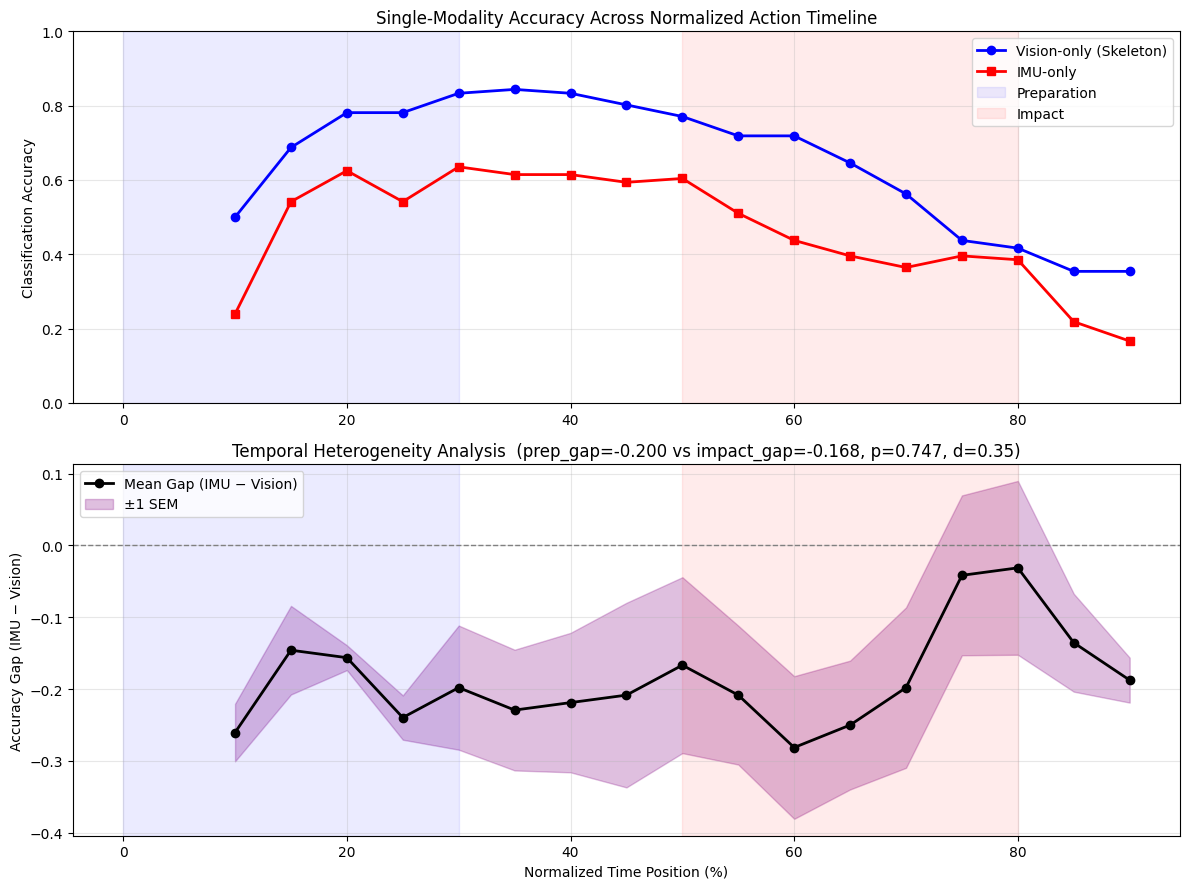

Figure saved.


In [ ]:
# ============================================================
# CELL 9: 画图
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# --- 图1：绝对准确率 ---
axes[0].plot(time_centers, accs_v, 'b-o', lw=2,
             label='Vision-only (Skeleton)')
axes[0].plot(time_centers, accs_i, 'r-s', lw=2,
             label='IMU-only')
axes[0].axvspan(0,  30, alpha=0.08, color='blue',  label='Preparation')
axes[0].axvspan(50, 80, alpha=0.08, color='red',   label='Impact')
axes[0].set_ylabel('Classification Accuracy')
axes[0].set_title('Single-Modality Accuracy Across Normalized Action Timeline')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 1)

# --- 图2：Gap曲线带误差 ---
axes[1].plot(time_centers, mean_gap, 'k-o', lw=2,
             label='Mean Gap (IMU − Vision)')
axes[1].fill_between(time_centers,
                      mean_gap - sem_gap,
                      mean_gap + sem_gap,
                      alpha=0.25, color='purple', label='±1 SEM')
axes[1].axhline(0, color='gray', ls='--', lw=1)
axes[1].axvspan(0,  30, alpha=0.08, color='blue')
axes[1].axvspan(50, 80, alpha=0.08, color='red')
axes[1].set_xlabel('Normalized Time Position (%)')
axes[1].set_ylabel('Accuracy Gap (IMU − Vision)')
axes[1].set_title(
    f'Temporal Heterogeneity Analysis  '
    f'(prep_gap={prep_g.mean():.3f} vs impact_gap={impact_g.mean():.3f}, '
    f'p={p_t:.3f}, d={d:.2f})'
)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/utd_mhad/crossover_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

In [ ]:
# 重新定义
EARLY_WINDOW  = (10, 40)   # Vision明显领先
LATE_WINDOW   = (70, 90)   # 两者接近

early_mask = (time_arr >= 10) & (time_arr <= 40)
late_mask  = (time_arr >= 70) & (time_arr <= 90)

early_g = gap_matrix[:, early_mask].mean(axis=1)
late_g  = gap_matrix[:, late_mask].mean(axis=1)

t_stat, p_t = ttest_rel(late_g, early_g)
_, p_w      = wilcoxon(late_g, early_g)
d = ((late_g.mean() - early_g.mean()) /
     np.sqrt((late_g.std()**2 + early_g.std()**2) / 2 + 1e-8))

print(f"Early gap: {early_g.mean():.4f} ± {early_g.std():.4f}")
print(f"Late  gap: {late_g.mean():.4f}  ± {late_g.std():.4f}")
print(f"t={t_stat:.3f}, p={p_t:.4f}, Cohen's d={d:.3f}")

Early gap: -0.2068 ± 0.0678
Late  gap: -0.1188  ± 0.1522
t=0.745, p=0.5106, Cohen's d=0.748


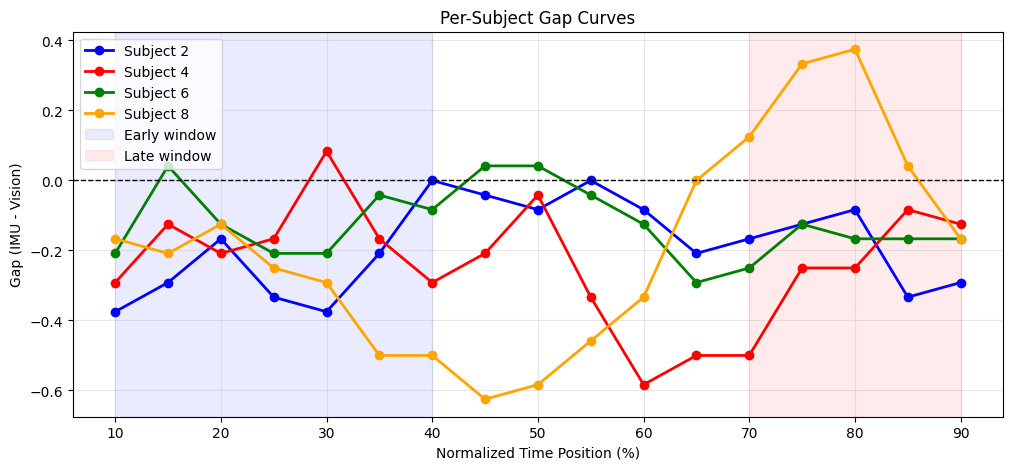

Subject 2 gap by time:
  t= 10%: -0.375
  t= 15%: -0.292
  t= 20%: -0.167
  t= 25%: -0.333
  t= 30%: -0.375
  t= 35%: -0.208
  t= 40%: +0.000
  t= 45%: -0.042
  t= 50%: -0.083
  t= 55%: +0.000
  t= 60%: -0.083
  t= 65%: -0.208
  t= 70%: -0.167
  t= 75%: -0.125
  t= 80%: -0.083
  t= 85%: -0.333
  t= 90%: -0.292


In [ ]:
# 看subject 2的完整gap曲线，找出哪里异常
plt.figure(figsize=(12, 5))
colors = ['blue', 'red', 'green', 'orange']
for i, subj in enumerate(TEST_SUBJECTS):
    plt.plot(time_centers, subject_gaps[subj],
             color=colors[i], marker='o',
             label=f'Subject {subj}', lw=2)

plt.axhline(0, color='black', ls='--', lw=1)
plt.axvspan(10, 40, alpha=0.08, color='blue',  label='Early window')
plt.axvspan(70, 90, alpha=0.08, color='red',   label='Late window')
plt.xlabel('Normalized Time Position (%)')
plt.ylabel('Gap (IMU - Vision)')
plt.title('Per-Subject Gap Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 同时打印subject 2的逐时间点数据
print("Subject 2 gap by time:")
for t, g in zip(time_centers, subject_gaps[2]):
    print(f"  t={t:3d}%: {g:+.3f}")